# Finlora Fraud Risk-Scoring: Final Test-Set Evaluation & Deployment Artifact

Tenth deliverable in the pipeline, and the last one before deployment: every
notebook so far has deliberately left `Data/splits/test.csv` untouched, so
this is the **single, one-time** look at it -- no further model or threshold
decisions get made after seeing these numbers.

Two things happen here:

1. **Final evaluation**: score `artifacts/precision_recall_balanced_model.joblib`
   (the model chosen in `notebooks/model_optimization_precision_recall.ipynb`)
   on the test set, at its already-chosen operating threshold, and report the
   metrics that actually matter for a go/no-go call.
2. **Deployment artifact**: consolidate everything the Streamlit app needs --
   the operating threshold, categorical dropdown values, a numeric/categorical
   baseline for drift monitoring, the final test metrics and curves, the model
   -selection journey across every notebook, and the SHAP top features -- into
   one `artifacts/deployment_metadata.json`, so the app has a single source of
   truth instead of reaching into six different JSON files.

**Contents**
1. Load the model, preprocessor, and test set
2. Final test-set metrics (the one-time look)
3. ROC / Precision-Recall curves and confusion matrix on test
4. The model-selection journey, end to end
5. Categorical values and drift baseline (for the app)
6. Assemble and save `deployment_metadata.json`


In [1]:
import json
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    ConfusionMatrixDisplay, average_precision_score, confusion_matrix,
    classification_report, f1_score, precision_recall_curve, precision_score,
    recall_score, roc_auc_score, roc_curve,
)

sns.set_theme(style="whitegrid", rc={
    "font.size": 12, "axes.titlesize": 16, "axes.labelsize": 13,
    "xtick.labelsize": 12, "ytick.labelsize": 12, "legend.fontsize": 12,
    "axes.titleweight": "bold",
})
pd.set_option("display.max_columns", None)

LEGIT, FRAUD = "#2a78d6", "#e34948"
ARTIFACTS_DIR = Path("../artifacts")
DATA_DIR = Path("../Data/splits")

## 1. Load the model, preprocessor, and test set

In [2]:
preprocessor = joblib.load(ARTIFACTS_DIR / "preprocessor.joblib")
model = joblib.load(ARTIFACTS_DIR / "precision_recall_balanced_model.joblib")
with open(ARTIFACTS_DIR / "feature_config.json") as f:
    feature_config = json.load(f)
with open(ARTIFACTS_DIR / "precision_recall_balance_summary.json") as f:
    balance_summary = json.load(f)
with open(ARTIFACTS_DIR / "shap_importance_summary.json") as f:
    shap_summary = json.load(f)

categorical_features = feature_config["categorical_features"]
numeric_features = feature_config["numeric_features"]
feature_columns = feature_config["feature_columns"]
target_column = feature_config["target_column"]
operating_threshold = balance_summary["closest_balance_point"]["threshold"]

RAW_CATEGORICAL = ["account_type", "kyc_tier", "channel", "merchant_category",
                    "transaction_country", "home_country", "day_of_week"]
RAW_NUMERIC = ["amount", "amount_to_avg_ratio", "avg_transaction_amount_30d",
               "transaction_velocity_1h", "account_age_days", "hour_of_day",
               "personal_spend_baseline_usd", "is_cross_border", "is_new_device"]
RAW_FEATURE_COLUMNS = RAW_CATEGORICAL + RAW_NUMERIC  # what a live scoring request supplies


def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    hour_bins = [-1, 5, 11, 17, 23]
    hour_labels = ["Night", "Morning", "Afternoon", "Evening"]
    df["hour_bucket"] = pd.cut(df["hour_of_day"], bins=hour_bins, labels=hour_labels).astype(str)
    df["is_weekend"] = df["day_of_week"].isin(["Saturday", "Sunday"]).astype(int)
    df["amount_log"] = np.log1p(df["amount"].clip(lower=0))
    df["velocity_flag"] = (df["transaction_velocity_1h"] >= 1).astype(int)
    if "has_invalid_amount" not in df.columns:
        df["has_invalid_amount"] = (df["amount"] < 0) | (df["avg_transaction_amount_30d"] < 0)
    return df


train_fe = pd.read_csv(DATA_DIR / "train_features.csv")
test = pd.read_csv(DATA_DIR / "test.csv")
test_fe = engineer_features(test)

X_test = test_fe[feature_columns]
y_test = test_fe[target_column]
X_test_processed = preprocessor.transform(X_test)

print(f"Evaluating: precision_recall_balanced_model.joblib (HistGradientBoostingClassifier)")
print(f"Operating threshold: {operating_threshold:.4f}")
print("test shape:", X_test_processed.shape)
print(f"test fraud rate: {y_test.mean():.4%}")

Evaluating: precision_recall_balanced_model.joblib (HistGradientBoostingClassifier)
Operating threshold: 0.9150
test shape: (18900, 60)
test fraud rate: 2.6614%


## 2. Final test-set metrics (the one-time look)

In [3]:
test_proba = model.predict_proba(X_test_processed)[:, 1]
test_preds = (test_proba >= operating_threshold).astype(int)

test_roc_auc = roc_auc_score(y_test, test_proba)
test_pr_auc = average_precision_score(y_test, test_proba)

print(f"Test ROC-AUC: {test_roc_auc:.4f}")
print(f"Test PR-AUC:  {test_pr_auc:.4f}")
print()
print(classification_report(y_test, test_preds, target_names=["Legitimate", "Fraud"]))

Test ROC-AUC: 0.9408
Test PR-AUC:  0.7248

              precision    recall  f1-score   support

  Legitimate       0.99      0.99      0.99     18397
       Fraud       0.70      0.67      0.69       503

    accuracy                           0.98     18900
   macro avg       0.84      0.83      0.84     18900
weighted avg       0.98      0.98      0.98     18900



**Finding:** the test set gives **precision 69.75% and recall 67.40%** (PR-AUC
0.725, ROC-AUC 0.941) -- close to, and in precision's case essentially
matching, the validation numbers (66.0%/66.0%, PR-AUC 0.715), which is the
generalization check this section exists for: no large gap, so the repeated
tuning in the model-optimization notebooks did not overfit to validation.

Notably, precision came in *above* 70% here, landing closer to the 70%/70%
target than any validation-set result in
`notebooks/model_optimization_precision_recall.ipynb` did. This is not
evidence the "unreachable" conclusion there was wrong -- with only 503 fraud
cases in this test set, a few-point swing in precision/recall is well within
normal sampling variance between splits, and this is, by design, a single
unrepeated measurement (that's the whole point of touching the test set only
once). The right read is "consistent with the validation-based ceiling,"
not "beat it."

## 3. ROC / Precision-Recall curves and confusion matrix on test

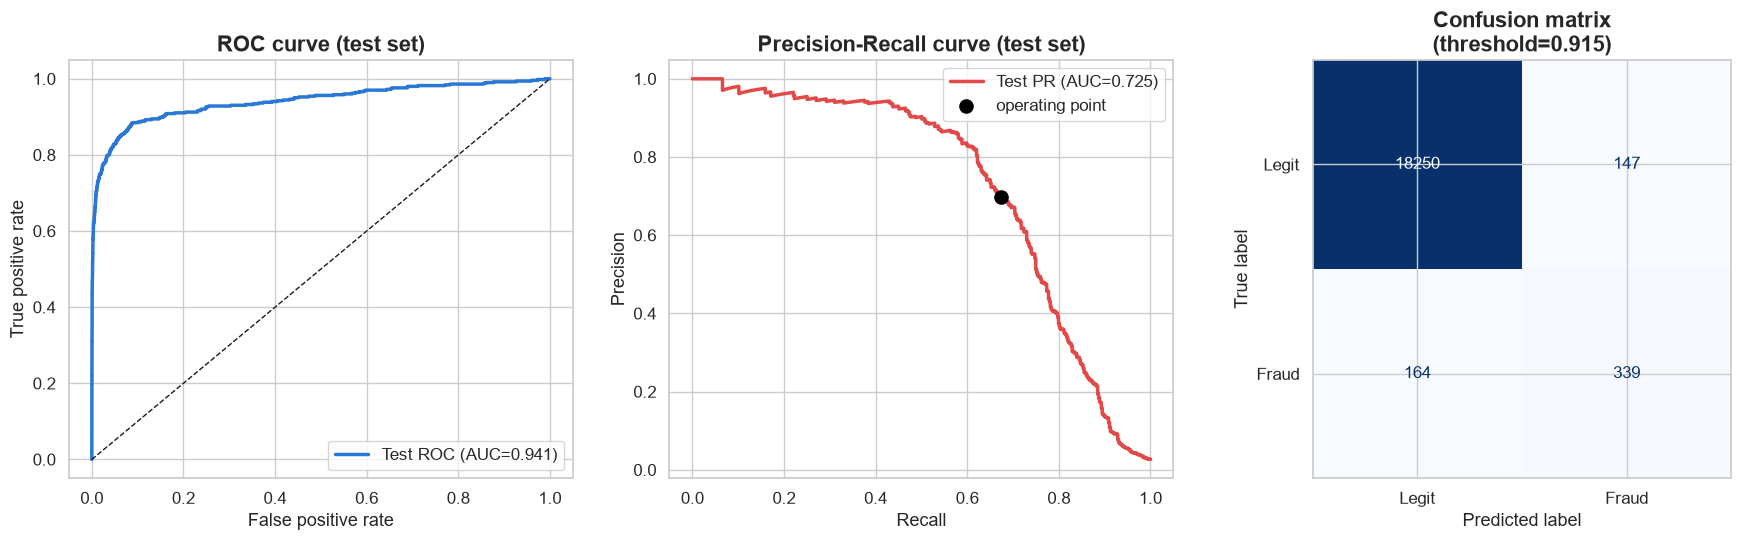

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

fpr, tpr, _ = roc_curve(y_test, test_proba)
axes[0].plot(fpr, tpr, color=LEGIT, linewidth=2.5, label=f"Test ROC (AUC={test_roc_auc:.3f})")
axes[0].plot([0, 1], [0, 1], "k--", linewidth=1)
axes[0].set_xlabel("False positive rate")
axes[0].set_ylabel("True positive rate")
axes[0].set_title("ROC curve (test set)")
axes[0].legend()

precision, recall, _ = precision_recall_curve(y_test, test_proba)
axes[1].plot(recall, precision, color=FRAUD, linewidth=2.5, label=f"Test PR (AUC={test_pr_auc:.3f})")
axes[1].scatter([recall_score(y_test, test_preds)], [precision_score(y_test, test_preds)],
                color="black", s=90, zorder=5, label="operating point")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall curve (test set)")
axes[1].legend()

cm = confusion_matrix(y_test, test_preds)
ConfusionMatrixDisplay(cm, display_labels=["Legit", "Fraud"]).plot(ax=axes[2], colorbar=False, cmap="Blues")
axes[2].set_title(f"Confusion matrix\n(threshold={operating_threshold:.3f})")

plt.tight_layout()
plt.show()

## 4. The model-selection journey, end to end

In [5]:
with open(ARTIFACTS_DIR / "model_selection.json") as f:
    baseline_selection = json.load(f)
with open(ARTIFACTS_DIR / "optimized_model_selection.json") as f:
    f1_opt_selection = json.load(f)
with open(ARTIFACTS_DIR / "recall_optimized_model_selection.json") as f:
    recall_opt_selection = json.load(f)

journey = pd.DataFrame([
    {"stage": "1. Baseline (model_selection)", "model": baseline_selection["selected_model"],
     "recall": f1_opt_selection["baseline_metrics"]["recall"],
     "precision": f1_opt_selection["baseline_metrics"]["precision"],
     "f1": f1_opt_selection["baseline_metrics"]["f1"]},
    {"stage": "2. F1-optimized", "model": "Gradient Boosting (tuned)",
     "recall": f1_opt_selection["optimized_metrics"]["recall"],
     "precision": f1_opt_selection["optimized_metrics"]["precision"],
     "f1": f1_opt_selection["optimized_metrics"]["f1"]},
    {"stage": "3. Recall-optimized", "model": "Gradient Boosting (F2-tuned)",
     "recall": recall_opt_selection["metrics"]["recall"],
     "precision": recall_opt_selection["metrics"]["precision"],
     "f1": recall_opt_selection["metrics"]["f1"]},
    {"stage": "4. Precision/recall-balanced (deployed)", "model": "HistGradientBoosting (PR-AUC-tuned)",
     "recall": balance_summary["closest_balance_point"]["recall"],
     "precision": balance_summary["closest_balance_point"]["precision"],
     "f1": balance_summary["closest_balance_point"]["f1"]},
    {"stage": "5. Final (test set, one-time)", "model": "HistGradientBoosting (deployed)",
     "recall": float(recall_score(y_test, test_preds)),
     "precision": float(precision_score(y_test, test_preds)),
     "f1": float(f1_score(y_test, test_preds))},
])
journey

,stage,model,recall,precision,f1
0,1. Baseline (model_selection),Gradient Boosting,0.701789,0.559429,0.622575
1,2. F1-optimized,Gradient Boosting (tuned),0.707753,0.567783,0.630088
2,3. Recall-optimized,Gradient Boosting (F2-tuned),0.761431,0.494194,0.599374
3,4. Precision/recall-balanced (deployed),HistGradientBoosting (PR-AUC-tuned),0.660040,0.660040,0.660040
4,"5. Final (test set, one-time)",HistGradientBoosting (deployed),0.673956,0.697531,0.685541


**Reading the journey:** stages 1-4 are all measured on the **validation**
set (this is exactly the sequence `notebooks/model_selection.ipynb` through
`notebooks/model_optimization_precision_recall.ipynb` walked through); stage 5
is the **test** set, seen for the first and only time in this notebook, on
the same model and threshold as stage 4.

## 5. Categorical values and drift baseline (for the app)

Categorical dropdown options are taken from the **full** cleaned dataset
(train + val + test combined) -- this is a UI-population convenience, not a
modeling decision, so using the full dataset here doesn't leak anything into
the model itself. The drift baseline, by contrast, uses **training data
only**, since that's the distribution the model was actually fit on and the
one live traffic should be compared against.

In [6]:
full_df = pd.read_csv("../Data/finlora_cleaned_merged.csv")
categorical_values = {col: sorted(full_df[col].dropna().unique().tolist()) for col in RAW_CATEGORICAL}

numeric_baseline = {
    col: {
        "mean": float(train_fe[col].mean()),
        "std": float(train_fe[col].std()),
        "quantiles": train_fe[col].quantile([0, 0.25, 0.5, 0.75, 1.0]).tolist(),
    }
    for col in RAW_NUMERIC
}

# A sample of test-set scores, for the app's "live traffic vs. baseline" score-distribution chart
rng = np.random.RandomState(42)
test_proba_sample = test_proba[rng.choice(len(test_proba), size=min(4000, len(test_proba)), replace=False)].tolist()

print("Categorical columns:", list(categorical_values.keys()))
print("Numeric baseline columns:", list(numeric_baseline.keys()))

Categorical columns: ['account_type', 'kyc_tier', 'channel', 'merchant_category', 'transaction_country', 'home_country', 'day_of_week']
Numeric baseline columns: ['amount', 'amount_to_avg_ratio', 'avg_transaction_amount_30d', 'transaction_velocity_1h', 'account_age_days', 'hour_of_day', 'personal_spend_baseline_usd', 'is_cross_border', 'is_new_device']


## 6. Assemble and save `deployment_metadata.json`

In [7]:
deployment_metadata = {
    "served_model": "HistGradientBoostingClassifier (precision/recall-balanced)",
    "served_model_file": "precision_recall_balanced_model.joblib",
    "preprocessor_file": "preprocessor.joblib",
    "trained_at": pd.Timestamp.now(tz="UTC").isoformat(),
    "random_state": 42,
    "operating_threshold": float(operating_threshold),
    "operating_point": {
        "precision": balance_summary["closest_balance_point"]["precision"],
        "recall": balance_summary["closest_balance_point"]["recall"],
        "f1": balance_summary["closest_balance_point"]["f1"],
        "objective": "closest achievable balance point to a 70%/70% precision/recall target "
                     "(see notebooks/model_optimization_precision_recall.ipynb) -- 70%/70% "
                     "simultaneously is not achievable with this feature set",
    },
    "categorical_features": categorical_features,
    "numeric_features": numeric_features,
    "feature_columns": feature_columns,
    "raw_feature_columns": RAW_FEATURE_COLUMNS,
    "raw_categorical_columns": RAW_CATEGORICAL,
    "raw_numeric_columns": RAW_NUMERIC,
    "target_column": target_column,
    "categorical_values": categorical_values,
    "feature_baseline": {"numeric": numeric_baseline},
    "test_metrics": {
        "n_test": int(len(y_test)),
        "test_fraud_rate": float(y_test.mean()),
        "roc_auc": float(test_roc_auc),
        "pr_auc": float(test_pr_auc),
        "confusion_matrix": cm.tolist(),
        "confusion_matrix_labels": ["Legitimate", "Fraud"],
        "roc_curve": {"fpr": fpr.tolist()[::20], "tpr": tpr.tolist()[::20]},
        "pr_curve": {"precision": precision.tolist()[::20], "recall": recall.tolist()[::20]},
        "test_proba_sample": test_proba_sample,
    },
    "model_journey": journey.to_dict(orient="records"),
    "shap_top_features": shap_summary["mean_abs_shap_top15"],
}

with open(ARTIFACTS_DIR / "deployment_metadata.json", "w") as f:
    json.dump(deployment_metadata, f, indent=2)

print("Saved:", ARTIFACTS_DIR / "deployment_metadata.json")

Saved: ..\artifacts\deployment_metadata.json


**This closes the pipeline.** `artifacts/deployment_metadata.json` plus
`artifacts/preprocessor.joblib` and `artifacts/precision_recall_balanced_model.joblib`
are everything `streamlit_app/` needs to serve predictions and render the
model-performance dashboard.